What is the Iris Dataset?
It's the most famous beginner dataset in ML. The goal is to classify flowers into 3 types based on 4 measurements.

3 flower types:

  0 → Setosa  |
  1 → Versicolor |
  2 → Virginica  |

4 features:
  Sepal Length, Sepal Width, Petal Length, Petal Width

  Best part — no cleaning needed. Zero nulls, perfect data. Pure focus on Decision Tree logic.

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier ,plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix


In [17]:
#load dataset
iris=load_iris()

In [18]:
df=pd.DataFrame(iris.data,columns=iris.feature_names)

In [19]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [23]:
df["target"]=iris.target

In [24]:
df["target"]

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int64

In [25]:
df.shape

(150, 5)

In [26]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [27]:
df['target'].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

In [28]:

X=df.drop('target',axis=1)
# axis=0 → drops a ROW    (by row index number)
# axis=1 → drops a COLUMN (by column name)
y=df['target']


In [29]:
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [30]:
y

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int64

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [32]:
print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

Train size: (120, 4)
Test size : (30, 4)


Note — no scaling needed for Decision Trees. Straight to training.


In [33]:
model=DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    random_state=42
)
model.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [35]:
y_pred=model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy : 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


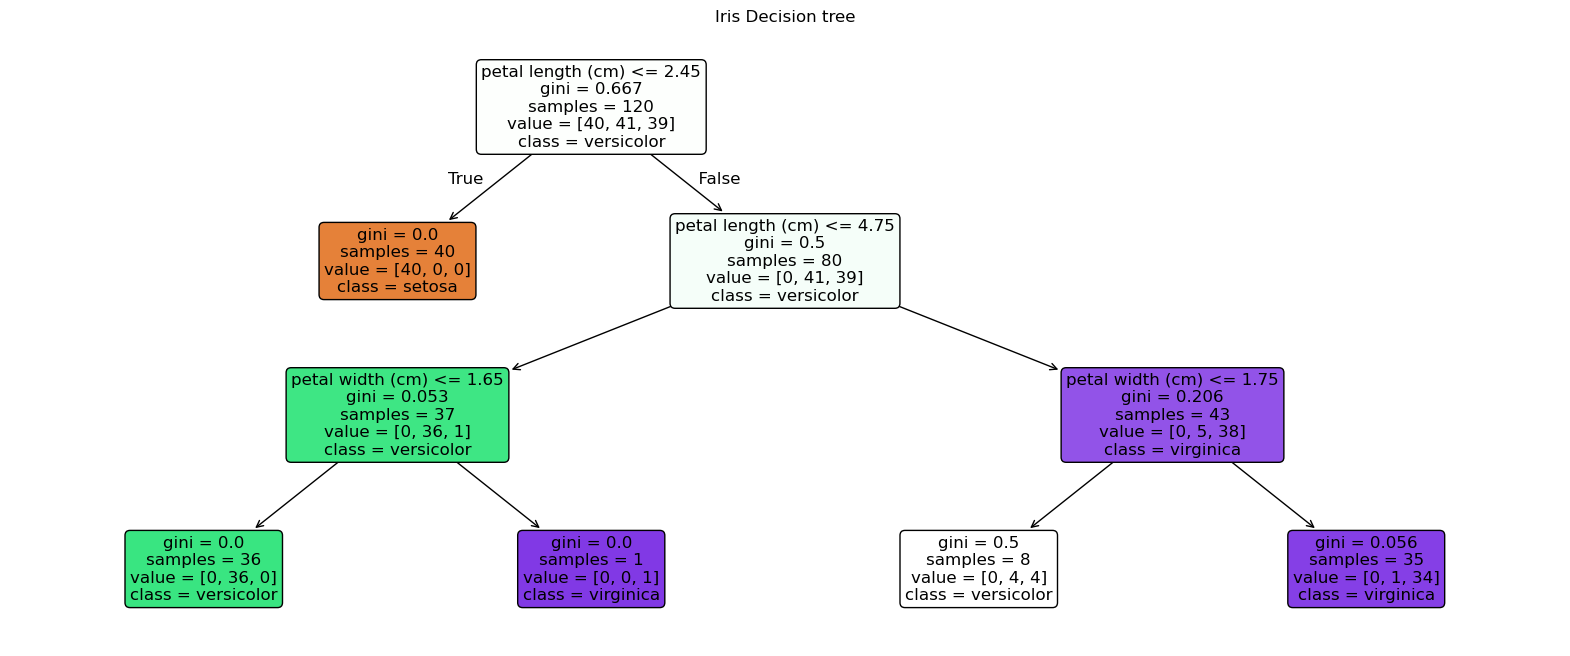

In [40]:
plt.figure(figsize=(20,8))
plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title("Iris Decision tree")
plt.show()

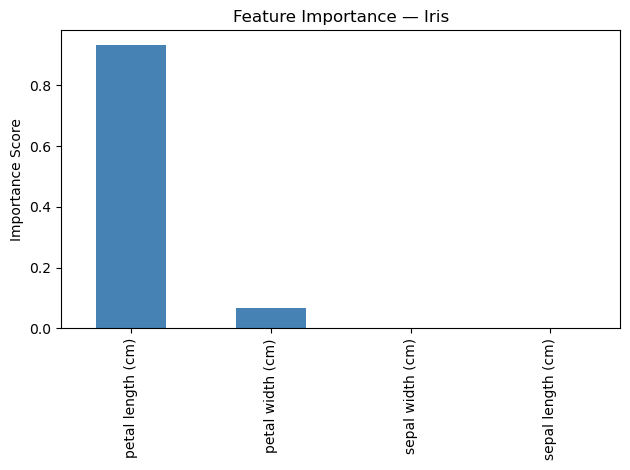

petal length (cm)    0.934626
petal width (cm)     0.065374
sepal width (cm)     0.000000
sepal length (cm)    0.000000
dtype: float64


In [45]:
importance=pd.Series(model.feature_importances_,index=iris.feature_names)
importance.sort_values(ascending=False).plot(kind='bar',color='steelblue')
plt.title("Feature Importance — Iris")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()


print(importance.sort_values(ascending=False))

In [46]:
train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc  = accuracy_score(y_test, y_pred)

print(f"Train Accuracy : {train_acc:.2f}")
print(f"Test Accuracy  : {test_acc:.2f}")
print(f"Gap            : {train_acc - test_acc:.2f}")

Train Accuracy : 0.96
Test Accuracy  : 1.00
Gap            : -0.04


In [47]:
# Best Depth Loop
for depth in range(1, 8):
    m = DecisionTreeClassifier(max_depth=depth, random_state=42)
    m.fit(X_train, y_train)
    train_a = accuracy_score(y_train, m.predict(X_train))
    test_a  = accuracy_score(y_test, m.predict(X_test))
    print(f"Depth {depth} → Train: {train_a:.2f}  Test: {test_a:.2f}")

Depth 1 → Train: 0.68  Test: 0.63
Depth 2 → Train: 0.95  Test: 0.97
Depth 3 → Train: 0.96  Test: 1.00
Depth 4 → Train: 0.97  Test: 1.00
Depth 5 → Train: 0.99  Test: 1.00
Depth 6 → Train: 1.00  Test: 1.00
Depth 7 → Train: 1.00  Test: 1.00


In [48]:
# [sepal length, sepal width, petal length, petal width]
new_flower = [[5.1, 3.5, 1.4, 0.2]]

result = model.predict(new_flower)
prob   = model.predict_proba(new_flower)

print("Flower type  :", iris.target_names[result[0]])
print("Probabilities:", prob)

Flower type  : setosa
Probabilities: [[1. 0. 0.]]


C:\Users\k9481\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\k9481\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
